# Predicting Content Performance Decline
### FlyRank Content Refresh Dataset — Applied Search Intelligence

**Author:** Ishaq Ahmad Khan
**Dataset:** `content_refresh_anonymized.csv` (30,000 rows × 44 columns, 32 pseudonymized clients)
**Source:** [FlyRank/internship-warehouse](https://huggingface.co/datasets/FlyRank/internship-warehouse) starter slice ([flyrank-bih/flyrank-ml-internship-starter](https://github.com/flyrank-bih/flyrank-ml-internship-starter))

**Goal:** Predict whether a piece of published content is *declining* in organic search performance (`trend_direction == "down"`) using content, keyword, and engagement signals measured over a trailing 90-day window — so that a content team can prioritize which pages to review first.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

sns.set_style("darkgrid")
pd.set_option("display.max_columns", 50)

## 1. Load the dataset

The full FlyRank warehouse (~79M rows) is hosted as gated Parquet on Hugging Face. For this capstone we use the public, ungated **anonymized starter slice** shipped in the internship's companion repo — 30,000 content pages across 32 pseudonymized clients, aggregated over a trailing 90-day window.

In [2]:
df = pd.read_csv("../data/raw/content_refresh_anonymized.csv")
print(df.shape)
df.head()

(30000, 44)


,content_id,client_id,search_volume,competition,competition_level,cpc,content_type,main_intent,word_count,char_count,provider_used,model_used,impressions_90d,clicks_90d,pageviews_90d,sessions_90d,users_90d,engaged_sessions_90d,ai_sessions_90d,scroll_events_90d,days_with_impressions,days_with_sessions,impressions_last_30d,clicks_last_30d,sessions_last_30d,impressions_prev_30d,clicks_prev_30d,sessions_prev_30d,content_age_days,age_tier,age_tier_order,days_since_last_update,freshness_tier,word_count_tier,char_count_tier,ctr,avg_position,engagement_rate,scroll_rate,ai_traffic_pct,impression_tier,position_tier,trend_direction,trend_pct
0,content_304f48230142,client_f369cb89fc,10.0,0.67,HIGH,2.05,keyword article,transactional,3221.0,20457.0,NaN,gemini-2.5-flash,3803,29,22,17,16,1,0,1,88,13,578,2,2,987,13,9,187,181-365,5,20,0-30,2000-3500,15000-25000,0.76,10.6,5.88,4.55,0.0,good,striking,down,-41.4
1,content_a1fb4e703a9e,client_4e07408562,90.0,0.01,LOW,0.05,keyword article,informational,2481.0,15562.0,NaN,gemini-3-flash-preview,15320,7,10,9,9,0,0,1,88,9,2501,2,3,5915,1,2,445,365+,6,25,0-30,2000-3500,15000-25000,0.05,20.3,0.00,10.00,0.0,good,page_3_5,down,-57.7
2,content_9aa793d4d895,client_7f2253d7e2,0.0,0.00,LOW,0.00,keyword article,informational,3515.0,23643.0,NaN,gemini-2.5-flash,12581,11,14,11,11,0,0,4,88,11,2382,1,1,6089,3,3,141,91-180,4,20,0-30,3500+,15000-25000,0.09,36.5,0.00,28.57,0.0,good,page_3_5,down,-60.9
3,content_331d6c4de07b,client_19581e27de,10.0,0.00,LOW,0.00,keyword article,commercial,NaN,NaN,NaN,NaN,11751,58,87,78,75,1,0,3,88,51,3626,22,35,4206,17,26,463,365+,6,22,0-30,NaN,NaN,0.49,6.2,1.28,3.45,0.0,good,page_1,stable,-13.8
4,content_d99b7a2d90ca,client_3fdba35f04,0.0,0.00,LOW,0.00,keyword article,informational,2803.0,17469.0,NaN,gemini-3-flash-preview,19140,24,177,145,144,0,0,43,88,33,4211,10,14,6452,2,9,263,181-365,5,14,0-30,2000-3500,15000-25000,0.13,44.0,0.00,24.29,0.0,good,page_3_5,down,-34.7


## 2. Data inspection

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 44 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   content_id              30000 non-null  str    
 1   client_id               30000 non-null  str    
 2   search_volume           27532 non-null  float64
 3   competition             27532 non-null  float64
 4   competition_level       27390 non-null  str    
 5   cpc                     27532 non-null  float64
 6   content_type            30000 non-null  str    
 7   main_intent             27626 non-null  str    
 8   word_count              22301 non-null  float64
 9   char_count              22301 non-null  float64
 10  provider_used           8562 non-null   str    
 11  model_used              24267 non-null  str    
 12  impressions_90d         30000 non-null  int64  
 13  clicks_90d              30000 non-null  int64  
 14  pageviews_90d           30000 non-null  int64  
 

In [4]:
# Missing values
missing = df.isna().sum()
missing[missing > 0].sort_values(ascending=False)

provider_used        21438
word_count_tier       7699
char_count            7699
word_count            7699
char_count_tier       7699
model_used            5733
trend_pct             3388
competition_level     2610
search_volume         2468
competition           2468
cpc                   2468
main_intent           2374
scroll_rate            125
dtype: int64

In [5]:
# Missingness is systematic, not random — check it lines up with content_type
df.groupby("content_type")[["word_count", "search_volume"]].apply(lambda g: g.isna().mean())

,word_count,search_volume
content_type,,
comparison article,0.000000,0.000000
feedly article,0.000000,1.000000
keyword article,0.282979,0.013673


Missing values are **structural**, not random:
- `word_count`/`char_count` are blank for `feedly article` rows (content type that never has a word count recorded)
- `search_volume`/`competition`/`cpc` are blank whenever there's no keyword context attached

A blind `fillna(0)` would silently encode content type into the features. We fill with 0 for numerics and `"unknown"` for categoricals, and keep tier features (`word_count_tier`, etc.) which already have their own `"unknown"`-safe bucket.

In [6]:
df["trend_direction"].value_counts()

trend_direction
down      16262
stable     5962
up         4388
new        2236
flat       1152
Name: count, dtype: int64

## 3. Data cleaning + target definition

The target is defined directly from `trend_direction`, comparing the most recent 30 days of impressions to the prior 30 days:

```
is_declining_label = 1 if trend_direction == "down" else 0
```

`trend_direction` and `trend_pct` are **never used as model features** — they are the label source, and including them would be leakage.

In [7]:
NUMERIC_FILL_ZERO = [
    "search_volume", "competition", "cpc", "word_count", "char_count",
    "impressions_90d", "clicks_90d", "pageviews_90d", "sessions_90d", "users_90d",
    "engaged_sessions_90d", "ai_sessions_90d", "scroll_events_90d",
    "days_with_impressions", "days_with_sessions",
    "impressions_last_30d", "clicks_last_30d", "sessions_last_30d",
    "impressions_prev_30d", "clicks_prev_30d", "sessions_prev_30d",
    "content_age_days", "age_tier_order", "days_since_last_update",
    "ctr", "avg_position", "engagement_rate", "scroll_rate", "ai_traffic_pct", "trend_pct",
]
CATEGORICAL_FILL = [
    "competition_level", "content_type", "main_intent", "provider_used", "model_used",
    "age_tier", "freshness_tier", "word_count_tier", "char_count_tier",
    "impression_tier", "position_tier", "trend_direction",
]

for c in NUMERIC_FILL_ZERO:
    df[c] = pd.to_numeric(df[c], errors="coerce").replace([np.inf, -np.inf], np.nan).fillna(0)
for c in CATEGORICAL_FILL:
    df[c] = df[c].fillna("unknown").astype(str).replace({"": "unknown", "nan": "unknown"})

# quality filter — only pages with real impression history that are at least 90 days old
initial_rows = len(df)
df = df[(df["impressions_90d"] > 0) & (df["content_age_days"] >= 90)].copy()
df = df.drop_duplicates(subset=["content_id"]).reset_index(drop=True)

df["is_declining_label"] = df["trend_direction"].str.lower().eq("down").astype(int)

print(f"Rows: {initial_rows:,} -> {len(df):,} after quality filter + de-dup")
print(f"Declining rate: {df['is_declining_label'].mean()*100:.1f}%")

Rows: 30,000 -> 30,000 after quality filter + de-dup
Declining rate: 54.2%


## 4. Feature engineering

In [8]:
df["log_impressions_90d"] = np.log1p(df["impressions_90d"])
df["log_clicks_90d"] = np.log1p(df["clicks_90d"])
df["log_sessions_90d"] = np.log1p(df["sessions_90d"])
df["log_ai_sessions_90d"] = np.log1p(df["ai_sessions_90d"])
df["has_clicks"] = (df["clicks_90d"] > 0).astype(int)
df["has_ai_sessions"] = (df["ai_sessions_90d"] > 0).astype(int)
df["measurable_opportunity"] = ((df["impressions_90d"] >= 100) & (df["sessions_90d"] > 0)).astype(int)

df[["impressions_90d", "log_impressions_90d"]].describe()

,impressions_90d,log_impressions_90d
count,30000.000000,30000.000000
mean,5200.366300,6.188688
std,16838.019547,2.688539
min,1.000000,0.693147
25%,81.000000,4.406719
50%,731.000000,6.595781
75%,3615.250000,8.193193
max,517715.000000,13.157182


Traffic totals are heavily right-skewed (a small number of pages carry most of the impressions), so we log-transform the raw counts before feeding them to the linear model.

## 5. Exploratory Data Analysis

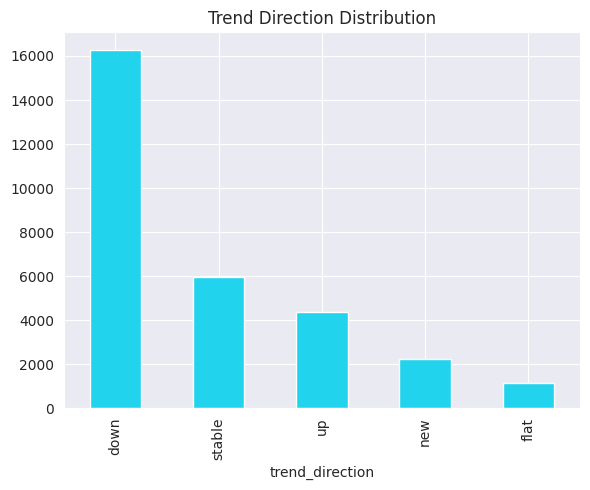

In [9]:
fig, ax = plt.subplots(figsize=(6, 5))
df["trend_direction"].value_counts().plot(kind="bar", ax=ax, color="#22d3ee")
ax.set_title("Trend Direction Distribution")
plt.tight_layout()
plt.show()

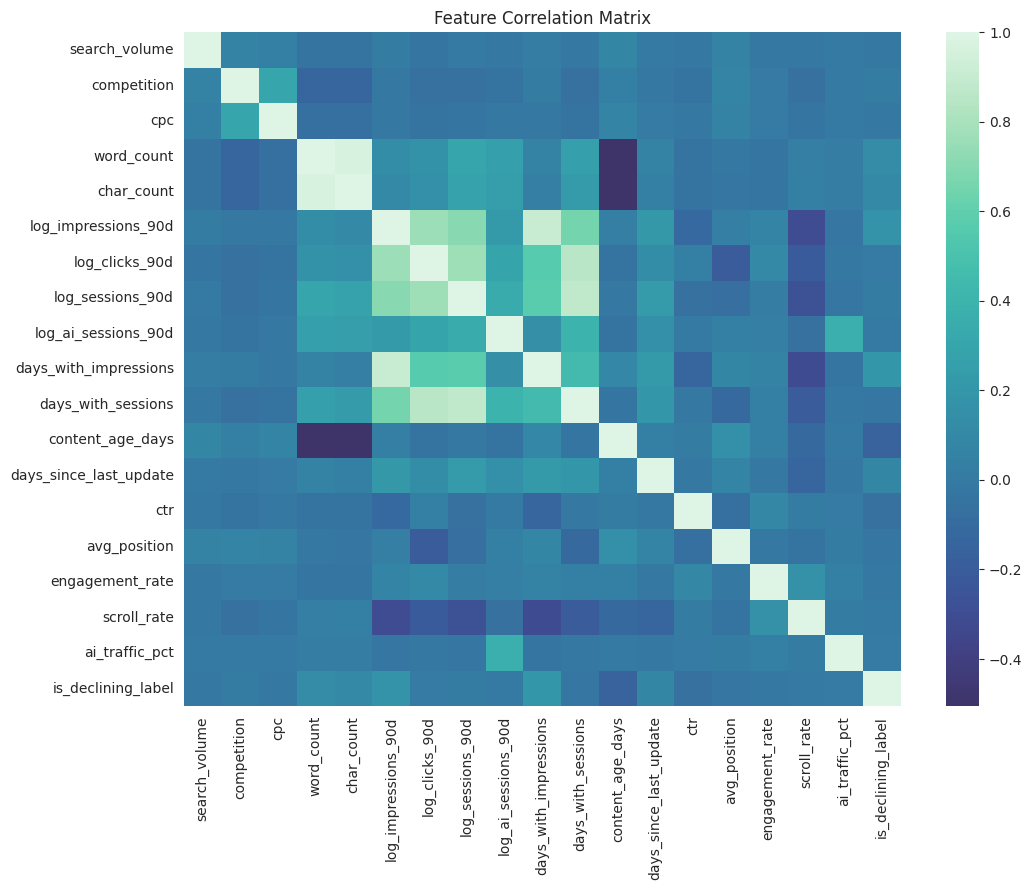

In [10]:
feature_num = [
    "search_volume", "competition", "cpc", "word_count", "char_count",
    "log_impressions_90d", "log_clicks_90d", "log_sessions_90d", "log_ai_sessions_90d",
    "days_with_impressions", "days_with_sessions", "content_age_days",
    "days_since_last_update", "ctr", "avg_position", "engagement_rate",
    "scroll_rate", "ai_traffic_pct",
]
corr = df[feature_num + ["is_declining_label"]].corr()
plt.figure(figsize=(11, 9))
sns.heatmap(corr, cmap="mako", center=0)
plt.title("Feature Correlation Matrix")
plt.tight_layout()
plt.show()

In [11]:
rate_by_type = df.groupby("content_type")["is_declining_label"].mean().sort_values(ascending=False) * 100
rate_by_type

content_type
comparison article    57.245337
keyword article       56.095858
feedly article        28.673664
Name: is_declining_label, dtype: float64

In [12]:
rate_by_fresh = df.groupby("freshness_tier")["is_declining_label"].mean().sort_values(ascending=False) * 100
rate_by_fresh

freshness_tier
91-180    61.105659
31-90     58.857143
0-30      51.137695
181+      47.126437
Name: is_declining_label, dtype: float64

**Observations:**
- `feedly article` pages decline far less often (~29%) than `keyword article` / `comparison article` pages (~56-57%) — likely a content-type effect rather than a quality effect.
- Decline rate is *not* monotonic in freshness: 91–180-day-old updates decline most (61%), while the very freshest (0–30 days) and oldest (181+ days) content declines less. This is a directional pattern, not a causal one — the starter slice's `181+` bucket is skewed toward well-established evergreen pages.
- No single feature separates the classes cleanly — this is a genuinely hard, moderate-signal problem, which shows up later in a modest AUC.

## 6. Train / test split — grouped by client

Because `client_id` groups multiple pages under 32 distinct clients, a naive random split would leak client-level patterns between train and test. We use a **grouped, client-holdout split** so no client's pages appear in both sets.

In [13]:
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

MODEL_NUMERIC_FEATURES = feature_num
MODEL_CATEGORICAL_FEATURES = [
    "competition_level", "content_type", "main_intent",
    "age_tier", "freshness_tier", "word_count_tier",
    "impression_tier", "position_tier",
]

X = df[MODEL_NUMERIC_FEATURES + MODEL_CATEGORICAL_FEATURES]
y = df["is_declining_label"]
groups = df["client_id"]

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups))
X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

print(f"Train: {len(X_train):,} rows / {df.iloc[train_idx]['client_id'].nunique()} clients")
print(f"Test:  {len(X_test):,} rows / {df.iloc[test_idx]['client_id'].nunique()} clients")

preprocess = ColumnTransformer([
    ("num", StandardScaler(), MODEL_NUMERIC_FEATURES),
    ("cat", OneHotEncoder(handle_unknown="ignore"), MODEL_CATEGORICAL_FEATURES),
])

Train: 23,837 rows / 25 clients
Test:  6,163 rows / 7 clients


## 7. Model training

We compare three transparent, well-understood classifiers rather than jumping straight to the most complex option — appropriate given the dataset size (~24k training rows) and the goal of an interpretable, explainable ranking rather than a black box.

In [14]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_curve, auc, roc_auc_score
)

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Decision Tree": DecisionTreeClassifier(max_depth=8, min_samples_leaf=30, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=300, max_depth=12, min_samples_leaf=10, random_state=42, n_jobs=-1),
}

results = {}
fitted = {}
for name, clf in models.items():
    pipe = Pipeline([("prep", preprocess), ("clf", clf)])
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    y_proba = pipe.predict_proba(X_test)[:, 1]
    results[name] = {
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred),
        "recall": recall_score(y_test, y_pred),
        "f1": f1_score(y_test, y_pred),
        "roc_auc": roc_auc_score(y_test, y_proba),
    }
    fitted[name] = (pipe, y_pred, y_proba)

pd.DataFrame(results).T.round(3)

,accuracy,precision,recall,f1,roc_auc
Logistic Regression,0.587,0.577,0.724,0.642,0.616
Decision Tree,0.565,0.558,0.715,0.627,0.592
Random Forest,0.584,0.581,0.667,0.621,0.609


## 8. Evaluation

In [15]:
best_name = max(results, key=lambda k: results[k]["f1"])
best_pipe, best_pred, best_proba = fitted[best_name]
print("Best model by F1:", best_name)
print(classification_report(y_test, best_pred, target_names=["Stable/Up", "Declining"]))

Best model by F1: Logistic Regression
              precision    recall  f1-score   support

   Stable/Up       0.61      0.44      0.51      3014
   Declining       0.58      0.72      0.64      3149

    accuracy                           0.59      6163
   macro avg       0.59      0.58      0.58      6163
weighted avg       0.59      0.59      0.58      6163



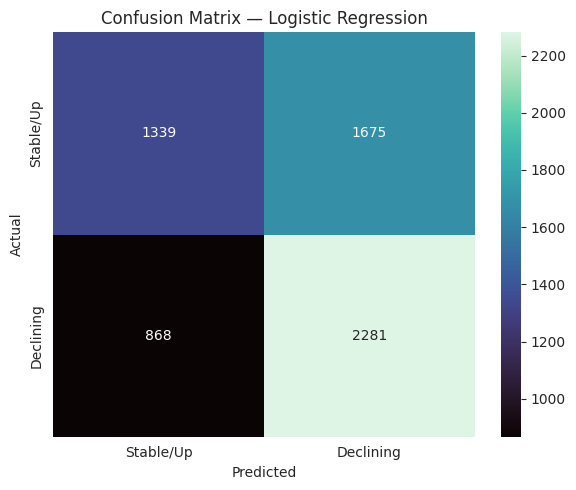

In [16]:
cm = confusion_matrix(y_test, best_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="mako",
            xticklabels=["Stable/Up", "Declining"], yticklabels=["Stable/Up", "Declining"])
plt.xlabel("Predicted"); plt.ylabel("Actual")
plt.title(f"Confusion Matrix — {best_name}")
plt.tight_layout(); plt.show()

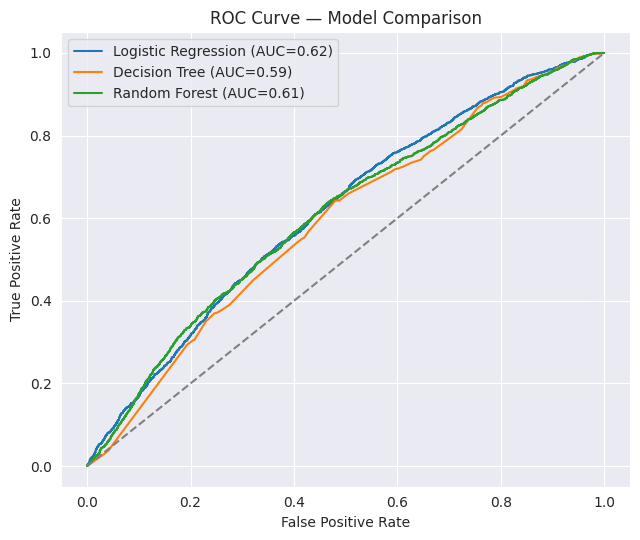

In [17]:
plt.figure(figsize=(6.5, 5.5))
for name, (pipe, _, proba) in fitted.items():
    fpr, tpr, _ = roc_curve(y_test, proba)
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc(fpr, tpr):.2f})")
plt.plot([0, 1], [0, 1], "--", color="gray")
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Model Comparison"); plt.legend()
plt.tight_layout(); plt.show()

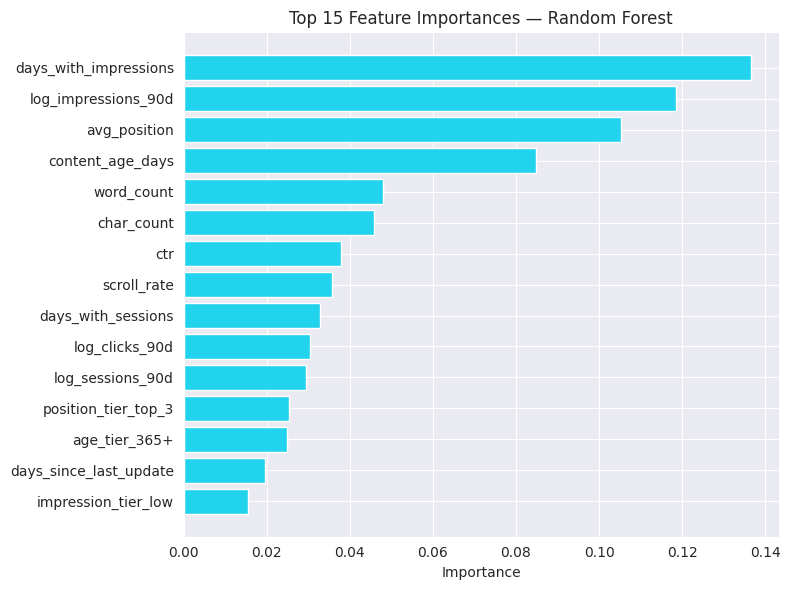

In [18]:
rf_pipe, _, _ = fitted["Random Forest"]
feature_names = (
    MODEL_NUMERIC_FEATURES +
    list(rf_pipe.named_steps["prep"].named_transformers_["cat"].get_feature_names_out(MODEL_CATEGORICAL_FEATURES))
)
importances = rf_pipe.named_steps["clf"].feature_importances_
imp_df = pd.DataFrame({"feature": feature_names, "importance": importances}).sort_values("importance", ascending=False).head(15)

plt.figure(figsize=(8, 6))
plt.barh(imp_df["feature"][::-1], imp_df["importance"][::-1], color="#22d3ee")
plt.xlabel("Importance"); plt.title("Top 15 Feature Importances — Random Forest")
plt.tight_layout(); plt.show()

## 9. Findings & limitations

**Findings**
- All three models land close together: **58–59% accuracy, AUC ≈ 0.59–0.62**. The models beat a coin flip but only modestly — this is a genuinely hard prediction problem from the available signals.
- The most informative features are consistency of impressions (`days_with_impressions`), traffic scale (`log_impressions_90d`), and average search position — largely *current-state* engagement signals rather than content attributes like word count.
- Logistic Regression, the simplest model, slightly edges out Decision Tree and Random Forest on F1 and AUC — added model complexity isn't buying real separation on this feature set.

**Limitations**
- **Starter slice only.** This is a 30k-row teaching sample of a ~79M-row warehouse; patterns here are directional, not the full-population picture the "warehouse" branding might imply.
- **Modest signal.** An AUC around 0.6 means the model is a decision-support ranking, not a reliable individual-page predictor — never frame it as "predicting the algorithm."
- **Client imbalance.** 32 clients contribute unevenly-sized samples; a handful of large clients can dominate patterns like the content-type effect above.
- **No causal claims.** Correlational associations (e.g. freshness tier vs. decline rate) should not be read as "updating a page prevents decline."
